<a href="https://colab.research.google.com/github/sekhahelina/bank_term_deposit_prediction/blob/main/deposit_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Імпорти необхідних бібліотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

In [ ]:
raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/bank-additional-full.csv', sep=';')
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# EDA - Exploratory Data Analysis

### 1 етап: Поглянемо на загальний опис даних перед тим як розпочати детальний аналіз.

In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Наші дані складаються з 21 стовпця та 41188 рядків. Пропусків немає, проте можемо припустити що вони винесені в окрему категорію unknown. Всі типи даних використані правильно.

In [ ]:
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Переглянувши загальний розподіл числових даних можемо зробити висновок, що дані не мають дивних відхилень чи неможливих аномалій. Вік у межах норми від 17 до 98, не має від`ємних значень там, де це неможливо. Тому можемо перейти до детальнішого ознайомлення окремо з кожним стовпцем.


### Розпочнемо з цільової змінної та переглянемо її розподіл.

In [ ]:
raw_df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


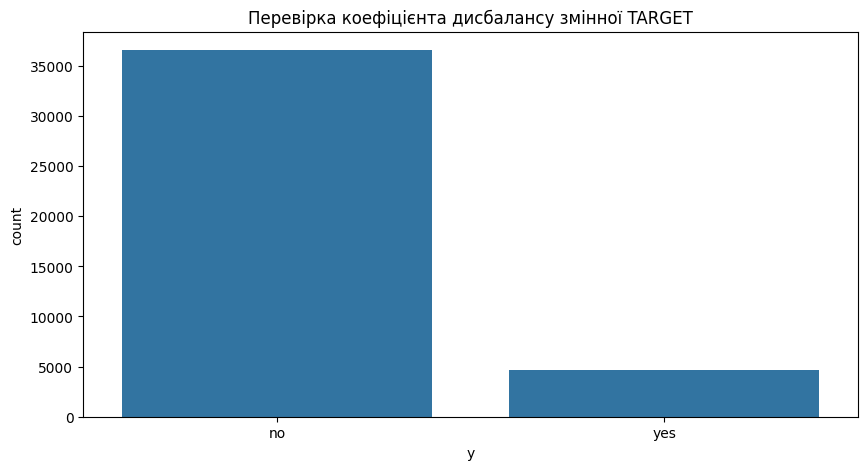

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(x = raw_df['y'], data = raw_df)
plt.title('Перевірка коефіцієнта дисбалансу змінної TARGET')
plt.show()

У результаті бачимо значний дисбаланс даних, 88% проти 11%. Варто взяти це до уваги для подальшого коректного обґрунтування графіків та розподілів. Також, пізніше це буде враховано для точного навчання моделей.

### Тепер поглянемо на кількість у кожній колонкці категорії unknown.

In [ ]:
for col in raw_df.select_dtypes('object'):
    print(raw_df[col].value_counts(dropna=False))

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26144
telephone    15044
Name: count, dtype: in

Категорія unknown складає незначну частку у більшості стовпчиків і не є критичною. Потребує уваги лише змінна education (1 731 невідоме значення). Детальніше обробку цих значень розглянемо на етапі препроцесингу даних.

In [ ]:
num_cols = raw_df.select_dtypes(include='number').columns
cat_cols = raw_df.select_dtypes(include='object').columns

In [ ]:
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

## Аналіз Числових колонок
### Переходимо до детальнішого вивчення числових колонок

Розпочнемо з огляду розподілу віку клієнтів (`age`).

In [ ]:
fig = px.histogram(
    raw_df,
    x='age',
    marginal='box',
    title='Розподіл віку клієнтів (age)',
    labels={'age': 'Вік', 'count': 'Кількість клієнтів'},
)
fig.show()

Проаналізувавши цей графік, можемо зробити висновок що розподіл віку клієнтів є правоскошеним (має довгий хвіст з правої сторони). Основна маса клієнтів знаходиться у віці від 30 до 50 років, а медіанний вік становить 38 років.

 На графіку спостерігаються статистичні викиди, клієнти віком 70+ років. Проте їх не варто вважати аномаліями чи помилками в даних, оскільки це реальна група потенційних клієнтів (пенсіонери).

In [ ]:

def plot_density_by_target(column_name):
    """
    Побудова графіку щільності розподілу для числової колонки у розрізі target (y)
    """
    group_no = raw_df[raw_df['y'] == 'no'][column_name].dropna()
    group_yes = raw_df[raw_df['y'] == 'yes'][column_name].dropna()

    fig = ff.create_distplot(
        hist_data=[group_no, group_yes],
        group_labels=['no (відмова)', 'yes (згода)'],
        show_rug=False
    )

    fig.update_layout(
        title_text=f'Щільність розподілу {column_name} за цільовою змінною (y)',
        xaxis_title=column_name,
        yaxis_title='Щільність (Density)',
        template='plotly_white'
    )

    fig.show()

In [ ]:
plot_density_by_target('age')

На цьому графіку можемо побачити, що люди молодшого віку(до 29 років) та старшого віку(60+ років) мають вищу конверсію (ймовірність відкриття строкового депозиту) порівняно з людьми середнього працездатного віку. Варто перевірити цю залежність спільно з роботою цих людей та освітою, щоб остаточно підтвердити гіпотезу.



In [ ]:
plot_density_by_target('campaign')

Знову бачимо дуже довгий хвіст справа, тому обрізаємо його щоб краще побачити розподіл.

In [ ]:
filtered_df = raw_df[raw_df['campaign'] <= 12]

group_no = filtered_df[filtered_df['y'] == 'no']['campaign']
group_yes = filtered_df[filtered_df['y'] == 'yes']['campaign']

fig = ff.create_distplot(
    hist_data=[group_no, group_yes],
    group_labels=['no (відмова)', 'yes (згода)'],
    bin_size=1,
    show_rug=False,
)

fig.update_layout(
    title_text='Розподіл кількості контактів (campaign) за результатами',
    xaxis_title='Кількість контактів під час кампанії',
    yaxis_title='Щільність (Density)',
    xaxis_range=[0, 12],
    template='plotly_white'
)

fig.show()

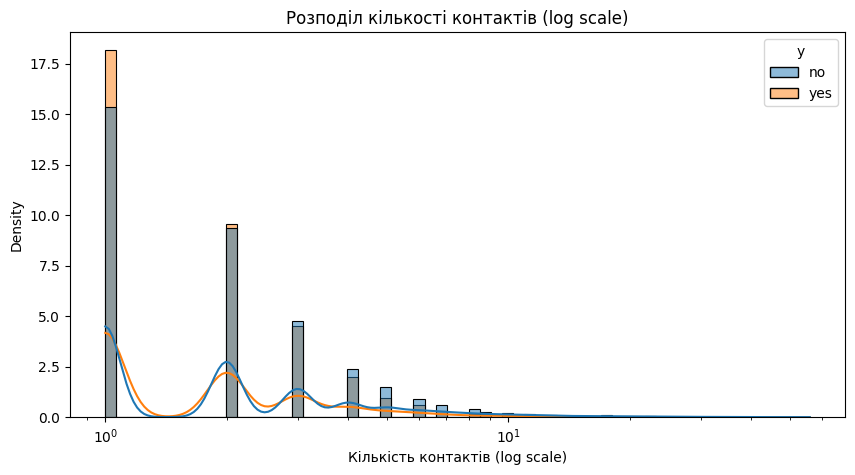

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=raw_df,
    x='campaign',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False,
    log_scale=True
)
plt.title('Розподіл кількості контактів (log scale)')
plt.xlabel('Кількість контактів (log scale)')
plt.show()

Додаткові дзвінки після 3–4 спроб не збільшують ймовірність згоди, а лише витрачають ресурси банку. Ефективніше обмежити кількість контактів на одного клієнта (наприклад, не більше 3-4 за кампанію). Клієнти погоджуються з 1-2 дзвінків, більше дзвінків не гарантує погождення, а навпаки зменшує ймовірність згоди.

In [ ]:
plot_density_by_target('duration')

Графік показує чітку залежність між тривалістю дзвінка (duration) та цільовою змінною y: чим триваліша розмова, тим вища ймовірність того, що клієнт погодиться на депозит (yes).

Проте, зміна duration створює витік даних. Тривалість розмови відома лише після здійснення дзвінка, коли результат (y) уже фактично існує. Оскільки мета моделі передбачити схильність клієнта до дзвінка , змінну duration необхідно вилучити з набору ознак для тренування моделі.

### Тепер розглянемо показник previous, який показує кількість контактів у попередній кампанії

<Axes: xlabel='previous', ylabel='Density'>

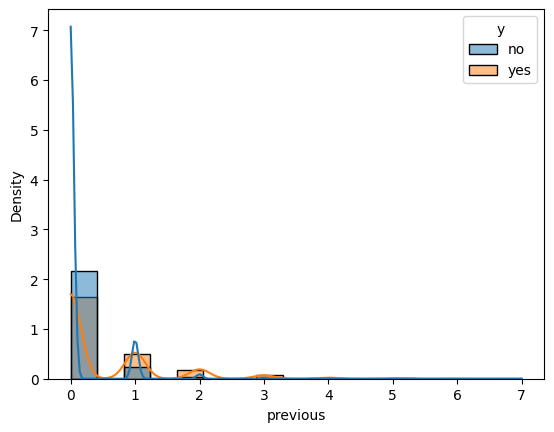

In [ ]:
sns.histplot(
    data=raw_df,
    x='previous',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

Наявність попередніх контактів (previous > 0) підвищує ймовірність того, що клієнт погодиться на депозит у поточній кампанії. Клієнти, з якими банк уже взаємодіяв раніше, більш схильні до згоди, ніж "холодні" клієнти (previous = 0).

Проте основний обсяг нових депозитів банк отримує саме від клієнтів з previous = 0, оскільки вони становлять абсолютну більшість вибірки.

### Розглянемо колонку pdays.

Ця категорія показує скільки пройшло днів з моменту останнього контакту з клієнтом в попередній кампанії. Значення 999 показує, що з клієнтом раніше не зв`язувались.

<Axes: xlabel='pdays', ylabel='Density'>

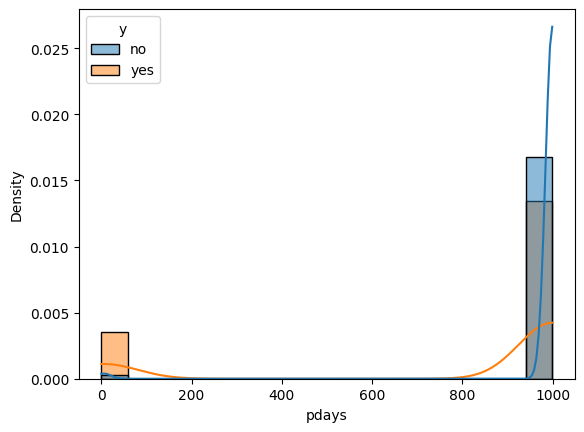

In [ ]:
sns.histplot(
    data=raw_df,
    x='pdays',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

На цьому графіку видно, що  більшість клієнтів у датасеті це люди, з якими раніше не контактували в межах попередніх кампаній (pdays = 999).

Створимо новий графік, щоб чітко порівняти кількість та конверсію між клієнтами, з якими вже зв'язувалися раніше, та тими, кому телефонували вперше.

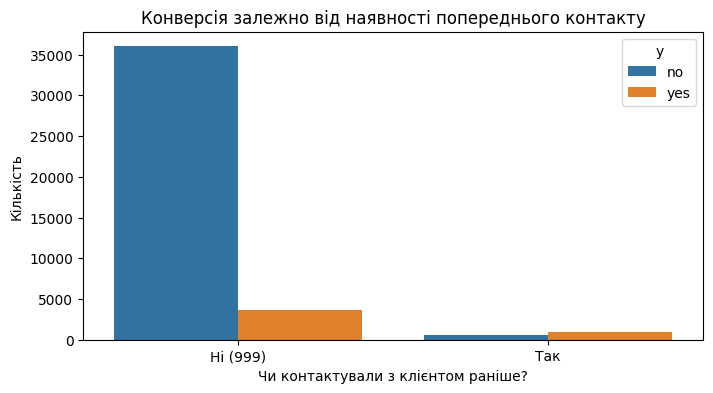

In [ ]:
raw_df['pdays_contacted'] = raw_df['pdays'].apply(lambda x: 'Ні' if x == 999 else 'Так')

plt.figure(figsize=(8, 4))
sns.countplot(data=raw_df, x='pdays_contacted', hue='y')
plt.title('Конверсія залежно від наявності попереднього контакту')
plt.xlabel('Чи контактували з клієнтом раніше?')
plt.ylabel('Кількість')
plt.show()

Тепер можемо зробити висновок, що база повторно контактованих клієнтів є значно лояльнішою та ефективнішою для дзвінків, хоча основний приплив депозитів банк все одно отримує за рахунок нових клієнтів (раніше не контактованих).

Також додатково розглянемо розподіл лише для клієнтів з якими зв`язувались в попередніх кампаніях.

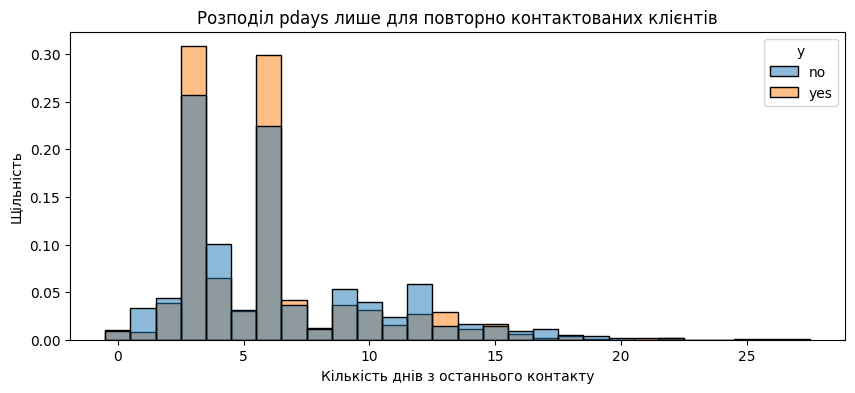

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=raw_df[raw_df['pdays'] != 999],
    x='pdays',
    hue='y',
    discrete=True,
    stat='density',
    common_norm=False
)
plt.title('Розподіл pdays лише для повторно контактованих клієнтів')
plt.xlabel('Кількість днів з останнього контакту')
plt.ylabel('Щільність')
plt.show()

Тут уже бачимо, що розподіл є двомодальним. На графіку чітко видно 2 виражені піки - 3 та 6 днів з моменту останнього контакту. Це означає, що банк найчастіше повторно зв`язується з клієнтами на 3 та 6 день, і це дає доволі позитивну динаміку конверсії. Після 6 днів щільність повторних контактів з клієнтами різко спадає.

### Далі перейдемо до аналізу  атрибутів соціально-економічного контексту
1. emp.var.rate – темп зміни зайнятості (щоквартальний показник).
2. cons.price.idx – індекс споживчих цін (щомісячний показник).
3. cons.conf.idx – індекс довіри споживачів (щомісячний показник).
4. euribor3m – ставка Euribor на 3 місяці (щоденний показник).
5. nr.employed – кількість працевлаштованих осіб (щоквартальний показник).

Переглянемо їхні розподіли, щоб краще зрозуміти динаміку даних

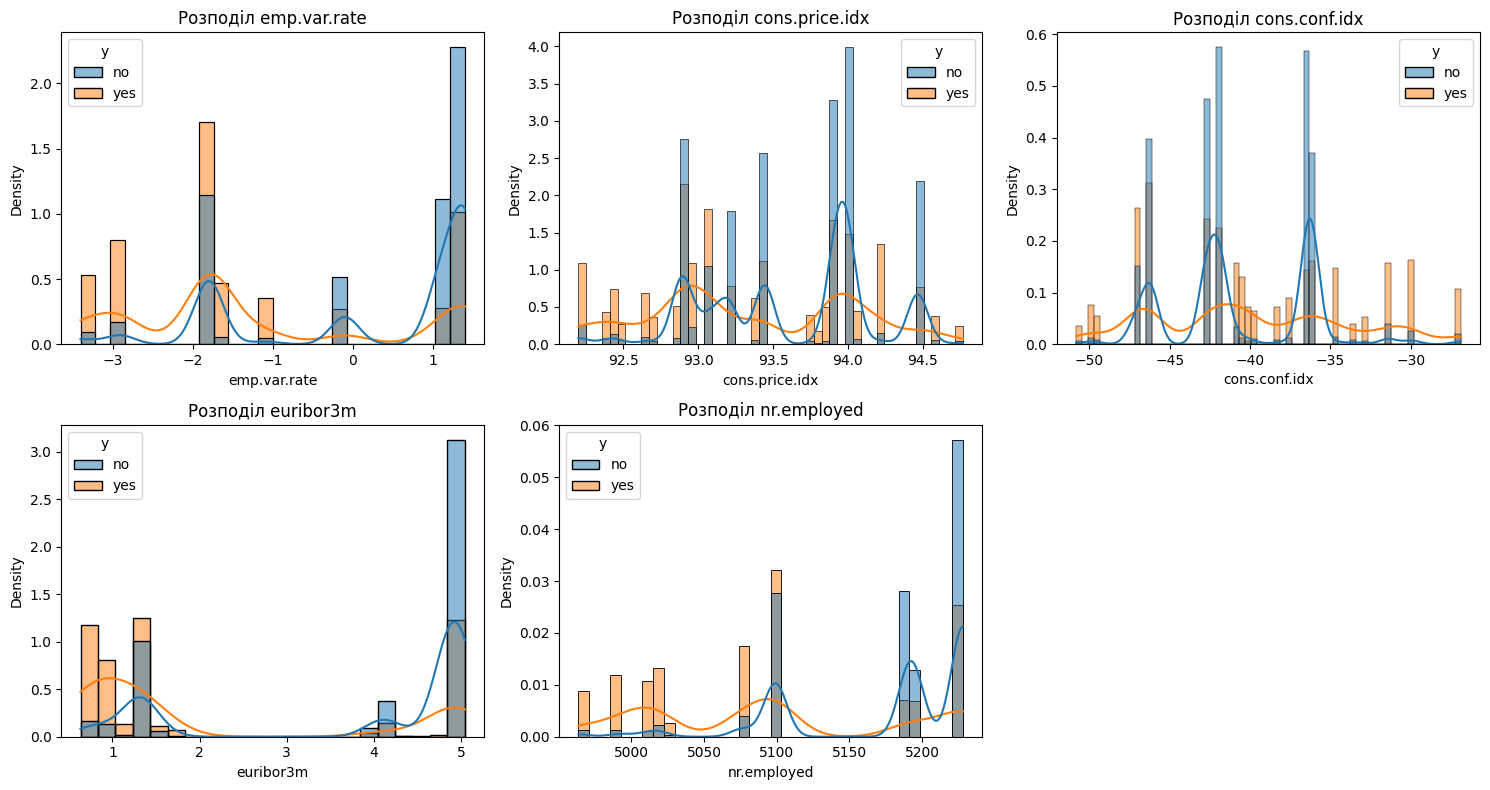

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
socio_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
fig.delaxes(axes.flatten()[5])
for ax, col in zip(axes.flatten(), socio_cols):
    sns.histplot(data=raw_df, x=col, hue='y', stat='density', common_norm=False, kde=True, ax=ax)
    ax.set_title(f'Розподіл {col}')

plt.tight_layout()
plt.show()

Проаналізувавши ці графіки бачимо, що клієнти набагато активніше відкривають депозити в періоди економічної нестабільності (emp.var.rate < 0, euribor3m < 2, nr.employed <= 5100). Можемо пояснити це тим, що в такі періоди на ринку праці люди намагаються мінімізувати ризики та віддають перевагу збереженню накопичень у банківських депозитах. За високих ставок або росту економіки інтерес до строкових депозитів у даній кампанії був суттєво нижчим.

Також на основі цих графіків бачимо, що cons.conf.idx (індекс довіри споживача) у нашому датасеті лише від'ємний, це може вказувати на період кризи у країні.

Графіки показують, що euribor3m, emp.var.rate та nr.employed рухаються майже однаково і мають дублюючу інформацію. Тому, можемо припустити, що вони мають доволі високу кореляцію.

### Наступним кроком перевіримо загальну кореляцію числових ознак

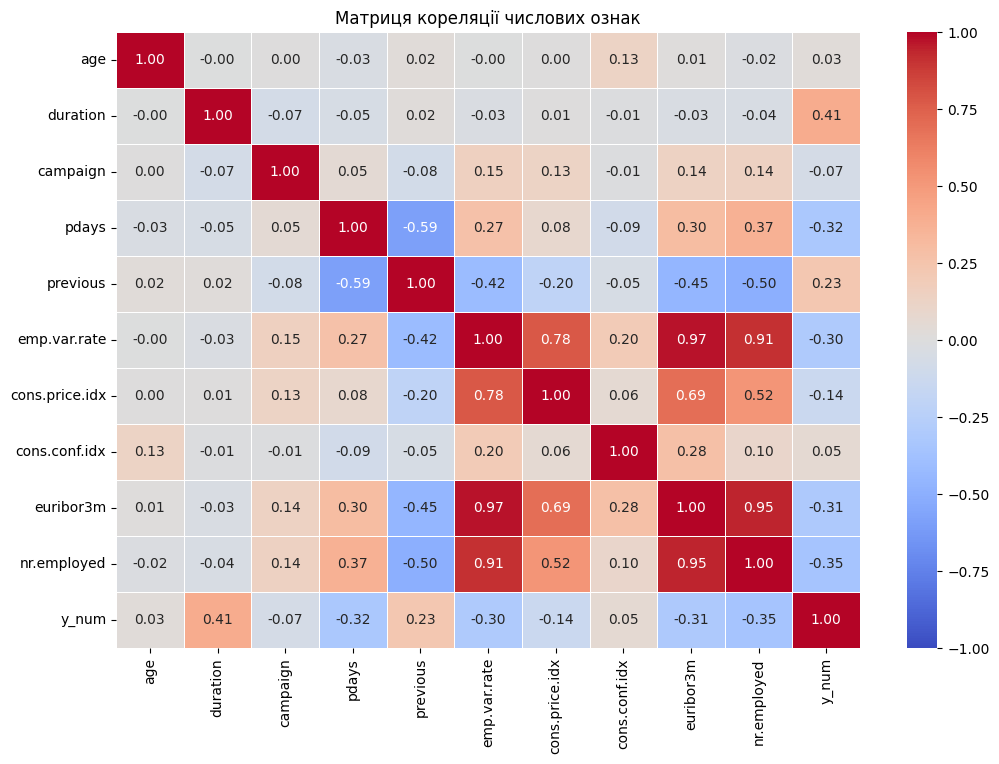

In [ ]:
plt.figure(figsize=(12, 8))

num_data = raw_df[num_cols].copy()
num_data['y_num'] = (raw_df['y'] == 'yes').astype(int)

corr_matrix = num_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матриця кореляції числових ознак')
plt.show()

Ця теплова картка підверджує наше припущення про мультиколінеарність атрибутів соціально-економічного контексту, а саме euribor3m, emp.var.rate, nr.employed та cons.price.idx. Це варто врахувати для подальшого навчання моделі, тому що не всі методи самостійно справляються з цим.

Також можемо побачити доволі високу від'ємну кореляцію між previous та pdays, це відбувається тому, що якщо з клієнтом раніше не контактували, то pdays = 999, як тільки previous>0, значення pdays падає до реальної кількості днів, які пройшли з минулого контакту. Через це високі значення previous відповідають низьким значенням pdays, що й дає сильну від'ємну кореляцію. Проте щоб зробити об'єктивні висновки потрібно коректно закодувати цю змінну, це буде зроблено на етапі препроцесингу даних.

## Аналіз категоріальних ознак

### Розпочнемо з колонки `job` (тип зайнятості клієнта)

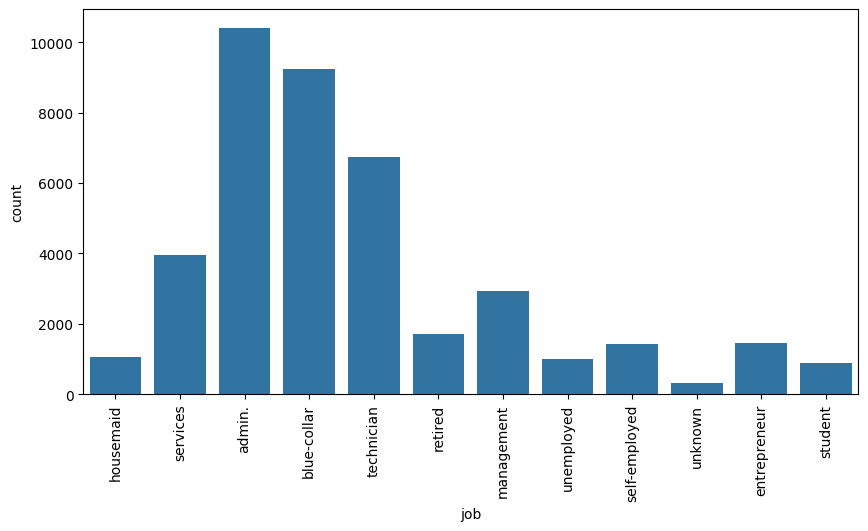

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "job")
plt.xticks(rotation = 90)
plt.show()

Можемо сказати, що у нашому датасеті найбільше клієнтів з адміністративною професією та різноробочих.

##Функція для побудови графіків категоріальних ознак

In [ ]:
def plot_relative_and_absolute(df, column_name, target_col='y'):
    """
    Будує два графіки для категоріальної колонки:
    1. Абсолютна кількість клієнтів за категоріями (Count)
    2. Відсоткова частка конверсії всередині кожної категорії (%)
    """
    # 1. Абсолютна кількість
    fig_count = px.histogram(
        df,
        x=column_name,
        color=target_col,
        barmode='group',
        title=f'Кількість клієнтів (Абсолютний обсяг) — {column_name}',
        category_orders={target_col: ['no', 'yes']},
        width=700,
        height=400
    )
    fig_count.update_layout(
        xaxis_title=column_name.capitalize(),
        yaxis_title='Кількість клієнтів',
        legend_title='Депозит'
    )
    fig_count.show()

    # 2. Відсотки (Нормалізований розподіл)
    fig_percent = px.histogram(
        df,
        x=column_name,
        color=target_col,
        barnorm='percent',
        barmode='group',
        title=f'Частка конверсії (%) — {column_name}',
        category_orders={target_col: ['no', 'yes']},
        width=700,
        height=400
    )
    fig_percent.update_layout(
        xaxis_title=column_name.capitalize(),
        yaxis_title='Частка (%)',
        legend_title='Депозит'
    )
    fig_percent.show()

In [ ]:
plot_relative_and_absolute(raw_df, 'job')

На цьому графіку бачимо підтвердження гіпотези, висунутої під час аналізу віку: відсотково найчастіше депозити відкривають студенти та пенсіонери, тоді як більш стабільні працевлаштовані категорії роблять це рідше.

### Перейдемо до аналізу рівня освіти клієнтів

In [ ]:
plot_relative_and_absolute(raw_df, 'education')

In [ ]:
raw_df.education.value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


У нашому наборі даних переважають люди з вищою та середньою освітою. Проте на цих графіках не спостерігається суттєвого впливу освіти на прийняття рішення, оскільки відсоткова конверсія у всіх категоріях практично однакова. Трішки відрізняється категорія неосвічених людей (illiterate), проте ми не можемо об'єктивно оцінювати це як патерн, оскільки в датасеті лише 18 таких записів.

Також можемо відзначити, що позитивно вирізняються категорії university.degree та unknown у них конверсія більша на кілька відсотків.

### Наступним кроком розглянемо сімейний стан клієнтів

In [ ]:
plot_relative_and_absolute(raw_df, 'marital')

Бачимо, що в нашому наборі даних значно переважають одружені люди, проте частка конверсії у всіх категоріях практично однакова. Можемо лише помітити, що самотні люди (single) на 4% більш схильні відкрити депозит, проте суттєвої значущості ця ознака нам не дає.

### Аналіз contact - тип зв’язку при останньому контакті

In [ ]:
plot_relative_and_absolute(raw_df, 'contact')

На цих графіках чітко простежується закономірність, що відсоткова конверсія серед клієнтів, з якими зв'язувалися по мобільному телефону (cellular), є значно вищою (майже втричі), ніж у разі контакту через стаціонарний телефон (telephone).

### Тепер перейдемо до ознаки poutcome.
- результат попередньої маркетингової кампанії

In [ ]:
plot_relative_and_absolute(raw_df, 'poutcome')

На цьому графіку бачимо підтвердження попереднього аналізу ознаки pdays. Клієнти, з якими раніше вже мали успішний контакт (poutcome = success), є найбільш лояльними та з високою ймовірністю (понад 60%) погоджуються на депозит. Проте в абсолютній кількості більшість угод банк отримує від нових клієнтів (або тих, з якими раніше не контактували), оскільки вони складають основну масу бази даних.

In [ ]:
plot_relative_and_absolute(raw_df, 'default')

In [ ]:
raw_df.default.value_counts()

,count
default,
no,32588
unknown,8597
yes,3


Проаналізувавши графік, можемо сказати, що серед людей, які мають дефолт, практично 0% оформлюють депозит (у всьому датасеті є лише 3 такі записи, і жоден із них не взяв депозит). Тому можемо припустити, що люди з кредитною заборгованістю взагалі не є цільовою аудиторією для відкриття депозитів.

Також можемо побачити, що значення unknown містить високу інформативність: конверсія в цій групі становить лише 5% проти 13% у групі default = no. Тому значення unknown у цій змінній не можна видаляти чи заповнювати модою, оскільки воно слугує сильною ознакою нижчої лояльності клієнта.

На етапі препроцесингу даних варто буде розділити цю категорію саме на unknown та no, тому що для окремої категорії, 3 значення default = yes це дуже мало.


## Комбіновані графіки
Після аналізу усіх ознак переходимо до побудови комбінованих графіків для виявлення нових закономірностей чи підтвердження гіпотез

In [ ]:
# Фільтруємо лише ті записи, де y == 'yes'
yes_df = raw_df[raw_df['y'] == 'yes']

fig = px.histogram(
    yes_df,
    x='education',
    color='job',
    barmode='group',
    title='Кількість позитивних депозитів за рівнем освіти та професією',
    labels={'education': 'Освіта', 'job': 'Професія', 'count': 'Кількість'}
)

fig.update_layout(xaxis_title='Рівень освіти', yaxis_title='Кількість (y = yes)')
fig.show()

Офісні працівники та спеціалісти з вищою освітою є головним атрибутом прибутку банку за абсолютним обсягом залучених депозитів. Вища та середня освіта (university.degree, high.school, professional.course) формують переважну більшість позитивних відповідей. Також у цих категоріях представлений широкий спектр професій (admin., technician, services, management).

Натомість у базовій освіті (basic.4y, basic.6y, basic.9y) абсолютним лідером є робітничі професії (blue-collar).

In [ ]:
fig = px.histogram(
    yes_df,
    x='poutcome',
    color='contact',
    barmode='stack',
    title='Кількість позитивних депозитів за результатом<br>попереднього контакту та способом зв`язку',
    labels={'poutcome': 'Результат попереднього дзвінка', 'count': 'Кількість (y = yes)', 'contact': 'Спосіб зв\'язку'}
)

fig.update_layout(xaxis_title='Результат попереднього дзвінка', yaxis_title='Кількість (y = yes)')
fig.show()

Мобільний зв'язок суттєво переважає міський в усіх трьох групах (nonexistent, failure, success). Це підтверджує, що мобільний телефон є універсально кращим способом зв'язку, а не просто переважає через якийсь один специфічний сегмент.Незалежно від того, чи клієнт новий, чи мав невдалий/вдалий досвід раніше завжди варто телефонувати на мобільний

In [ ]:
fig = px.histogram(
    yes_df,
    x='month',
    color='poutcome',
    barmode='stack',
    title="Кількість позитивних депозитів за місяцями<br>та результатом минулого контакту",
    labels={
        'month': 'Місяць останнього контакту',
        'count': 'Кількість (y = yes)',
        'poutcome': 'Результат попереднього контакту'
    },
    category_orders={'month': ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']} # Хронологічний порядок
)

fig.update_layout(
    xaxis_title='Місяць',
    yaxis_title='Кількість позитивних депозитів (yes)'
)

fig.show()

Графік демонструє, що в абсолютній кількості найбільше позитивних депозитів банк отримує у травні за рахунок нових клієнтів (nonexistent), для яких це перший контакт. Водночас у весняні (березень) та осінньо-зимові місяці (вересень, жовтень, грудень) суттєво зростає частка успішних угод від клієнтів із позитивним попереднім досвідом (success), що свідчить про високу лояльність цієї групи та ефективність повторних звернень у ці періоди.

In [ ]:
fig = px.histogram(
    yes_df,
    x='housing',
    color='loan',
    barmode='group',
    title="Кількість позитивних депозитів за наявністю іпотеки та кредиту",
    labels={
        'housing': 'Наявність іпотеки',
        'count': 'Кількість (y = yes)',
        'contact': 'Наявність кредиту'
    },
  )

fig.update_layout(
    xaxis_title='Наявність іпотеки',
    yaxis_title='Кількість позитивних депозитів (yes)'
)

fig.show()

Найбільша група серед тих, хто взяв депозит це люди без споживчого кредиту (loan = no). Як у групі з іпотекою (housing = yes), так і у групі без іпотеки (housing = no) абсолютна більшість позитивних відповідей припадає на людей без споживчих кредитів. Помаранчеві стовпчики в обох категоріях незначні (близько 300–400 людей). Це свідчить про те, що загальна кількість клієнтів із відкритим депозитом, які мають споживчий кредит, є дуже малою.

## Підсумок EDA

Гіпотези впливу ознак на цільову змінну:
1. Ефективність попередніх кампаній (poutcome)

Значення poutcome = success критично підвищує ймовірність відкриття депозиту (конверсія зростає до ~65% порівняно з базовими ~11%).

2. Історія взаємодії (previous)

Попередній контакт із клієнтом підвищує його схильність до позитивної відповіді. Проте в абсолютній кількості основний обсяг угод банк отримує від «холодних» (первинних) клієнтів за рахунок їхньої чисельної переваги в базі даних.

3. Віковий та соціальний вплив

Молодь (зокрема студенти) та пенсіонери демонструють вищу відсоткову конверсію порівняно з працездатною категорією середнього віку.

4. Макроекономічні чинники

Макроекономічні показники (euribor3m, emp.var.rate, cons.price.idx тощо) тісно пов'язані між собою (демонструють високу мультиколінеарність), і в періоди економічної нестабільності клієнти схильні частіше відкривати депозити.

5. Канал зв'язку (contact)

Звернення до клієнта через мобільний телефон (cellular) забезпечує майже втричі вищу ймовірність позитивної відповіді, ніж через стаціонарний (telephone).

Оскільки, цільова змінна у нас бінарного характеру, а саме yes/no, для вирішення цієї задачі потрібно обрати метод машинного навчання, який працює з бінарною класифікацією. Для базової моделі я б обрала логістичну регресію і пізніше порівнювала б її з більш складними моделями (DesicionTree, KNN, XGBoost).

Для того щоб коректно обрати метрику для оцінки моделі, потрібно детально проаналізувати нашу бізнес-ціль. Оскільки мета вирішення нашої задачі полягає у передбаченні, чи оформить клієнт в банку строковий депозит, потрібно визначити, що для бізнесу дорожче: обрати тип помилки, чи нам важливіше не пропустити жодного клієнта, який потенційно погодиться на депозит, чи варто зосередитись на клієнтах, які не погодяться, щоб не витрачати кошти та час бізнесу на них.

У першому випадку більш важливим показником буде Recall, оскільки він показує, яку частку клієнтів, які насправді погодилися на депозит, модель змогла правильно ідентифікувати. Водночас високий Recall можна отримати ціною значної кількості хибнопозитивних прогнозів, коли клієнтам, які не зацікавлені в депозиті, модель помилково прогнозує позитивний результат. У такому випадку важливим стає Precision, який показує, яка частка клієнтів із позитивним прогнозом дійсно погодиться на депозит. Accuracy у нашому випадку не є оптимальною основною метрикою, оскільки цільова змінна є незбалансованою, і модель може отримати високу Accuracy переважно за рахунок правильного прогнозування більш численного класу no. F1-score є компромісом між Precision та Recall, оскільки враховує обидва показники та буде знижуватися як при великій кількості пропущених потенційних клієнтів, так і при надмірній кількості хибнопозитивних прогнозів.

Проте, якщо бізнес-пріоритетом банку є максимальне залучення капіталу і вартість пропущеного клієнта (False Negative) суттєво перевищує вартість одного телефонного дзвінка (False Positive), доцільніше використовувати метрику F_2-score або налаштовувати поріг класифікації (threshold) з акцентом на мінімізацію пропущених депозитів.

Додатково можна використовувати ROC-AUC, оскільки ця метрика не залежить від обраного порогу класифікації та дозволяє оцінити здатність моделі розділяти позитивний і негативний класи на різних значеннях threshold. Після вибору моделі threshold можна підібрати на validation-вибірці з урахуванням F1-score.

# Препроцесинг даних

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
import pandas as pd
import numpy as np

In [ ]:
raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/bank-additional-full.csv', sep=';')
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y', 'pdays_contacted'],
      dtype='object')

Почнемо з кодування категоріальних колонок

In [ ]:
raw_df.education.value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [ ]:
education_map = {
    'basic.4y': 'basic.education',
    'basic.6y': 'basic.education',
    'basic.9y': 'basic.education',
    'illiterate': 'basic.education'
}

raw_df['education'] = raw_df['education'].replace(education_map)
raw_df['education'].value_counts()

,count
education,
basic.education,12531
university.degree,12168
high.school,9515
professional.course,5243
unknown,1731


Було прийнято рішення об'єднати категорії basic.4y, basic.6y, basic.9y та illiterate в одну групу basic.education. Попередній аналіз показав відсутність суттєвої різниці у поведінці цих груп, тому таке групування дозволяє зменшити розмірність даних та уникнути розрідженості.

In [ ]:
raw_df['pdays'] = raw_df['pdays'].replace(999, -1)
raw_df['pdays'].describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


Значення 999 у pdays є спеціальним кодом, що означає відсутність попереднього контакту. Щоб не трактувати його як реальну кількість днів, було створено бінарну ознаку pdays_contacted, а значення 999 замінено на -1 як спеціальний маркер відсутності попереднього контакту.

У результаті аналізу було вирішено закодувати ознаки default, housing та loan як бінарні (зі значенням -1 для unknown). Інші категоріальні ознаки закодовано за допомогою One-Hot Encoding, щоб уникнути створення штучного порядку між категоріями. Для масштабування числових змінних обрано StandardScaler.

Попри відсутність пропущених значень у датасеті, до пайплайну було додано імпутацію (заповнення) за допомогою середнього та найчастішого значень на випадок появи нових даних.

Дані розділено на три вибірки (train, validation, test) обов'язково з параметром stratify, оскільки цільова змінна є незбалансованою.

Для коректної оцінки моделі заплановано провести серію експериментів:

1. З використанням та без використання атрибута duration (для оцінки витоку даних);

2. З видаленням однієї з економічних змінних для усунення сильної мультиколінеарності;

3. З застосуванням технік ресемплінгу (Oversampling та Undersampling) для перевірки їх доцільності у фінальному рішенні.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
import importlib
import preprocess_term_deposit
from preprocess_term_deposit import preprocess_data
importlib.reload(preprocess_term_deposit)


<module 'preprocess_term_deposit' from '/content/preprocess_term_deposit.py'>

In [ ]:
importlib.reload(preprocess_term_deposit)

<module 'preprocess_term_deposit' from '/content/preprocess_term_deposit.py'>

In [ ]:
def compute_auroc_and_build_roc(model, inputs, targets, name='', plot: bool = True):
  # Predict probabilities
  probs = model.predict_proba(inputs)[:, 1]
  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, probs)
  # Compute AUROC
  roc_auc = auc(fpr, tpr)

  print(f'AUROC for {name}: {roc_auc:.2f}')

  if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(
            fpr,
            tpr,
            color='darkorange',
            lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})'
        )
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve ({name})')
        plt.legend(loc='lower right')
        plt.show()

  return

In [ ]:

def evaluate_model(model_name, model, X_train, y_train, X_val, y_val):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_precision = precision_score(y_train, train_preds, pos_label=1)
    train_recall = recall_score(y_train, train_preds, pos_label=1)
    train_f1 = f1_score(y_train, train_preds, pos_label=1)

    val_precision = precision_score(y_val, val_preds, pos_label=1)
    val_recall = recall_score(y_val, val_preds, pos_label=1)
    val_f1 = f1_score(y_val, val_preds, pos_label=1)

    if hasattr(model, "predict_proba"):
        train_probs = model.predict_proba(X_train)[:, 1]
        val_probs = model.predict_proba(X_val)[:, 1]

        train_roc_auc = roc_auc_score(y_train, train_probs)
        val_roc_auc = roc_auc_score(y_val, val_probs)
    else:
        train_roc_auc = None
        val_roc_auc = None

    return {
        'Model': model_name,
        'Train Precision': round(train_precision, 3),
        'Train Recall': round(train_recall, 3),
        'Train F1': round(train_f1, 3),
        'Train ROC-AUC': round(train_roc_auc, 3) if train_roc_auc is not None else None,
        'Validation Precision': round(val_precision, 3),
        'Validation Recall': round(val_recall, 3),
        'Validation F1': round(val_f1, 3),
        'Validation ROC-AUC': round(val_roc_auc, 3) if val_roc_auc is not None else None
    }

In [ ]:
results = []

# 1 Експеримент: Порівнюємо метрики базових моделей з параметром duration та без

## Логістична регресія

In [ ]:
data_log = preprocess_data(
    raw_df,
    scale_numeric=True,
)

X_train = data_log['X_train']
y_train = data_log['y_train']
X_val = data_log['X_val']
y_val = data_log['y_val']

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

print("\n Логістична регресія з параметром duration \n")

compute_auroc_and_build_roc(logreg, X_train, y_train, name='training', plot = False)
compute_auroc_and_build_roc(logreg, X_val, y_val, name='validation', plot = False)

results.append(evaluate_model('Logistic Regression ( + duration)', logreg, X_train, y_train, X_val, y_val))

# Logistic Regression без duration
raw_df_without_duration = raw_df.drop(
    columns=['duration']
)

data_without_duration = preprocess_data(
    raw_df_without_duration,
    scale_numeric=True
)

X_train_wo_dur = data_without_duration['X_train']
y_train_wo_dur = data_without_duration['y_train']
X_val_wo_dur = data_without_duration['X_val']
y_val_wo_dur = data_without_duration['y_val']

logreg2 = LogisticRegression(max_iter=1000, random_state=42)
logreg2.fit(X_train_wo_dur, y_train_wo_dur)

print("\n Логістична регресія без параметра duration \n")

compute_auroc_and_build_roc(logreg2, X_train_wo_dur, y_train_wo_dur, name='training', plot = False)
compute_auroc_and_build_roc(logreg2, X_val_wo_dur, y_val_wo_dur, name='validation', plot = False)

results.append(evaluate_model('Logistic Regression (baseline)', logreg2, X_train_wo_dur, y_train_wo_dur, X_val_wo_dur, y_val_wo_dur))


 Логістична регресія з параметром duration 

AUROC for training: 0.94
AUROC for validation: 0.94

 Логістична регресія без параметра duration 

AUROC for training: 0.79
AUROC for validation: 0.79


## KNN

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

print("\n KNN з параметром duration \n")

compute_auroc_and_build_roc(knn, X_train, y_train, name='training', plot=False)
compute_auroc_and_build_roc(knn, X_val, y_val, name='validation', plot=False)

results.append(
    evaluate_model('kNN (+ duration)', knn, X_train, y_train, X_val, y_val)
)


knn_no_dur = KNeighborsClassifier()
knn_no_dur.fit(X_train_wo_dur, y_train_wo_dur)

print("\n KNN без параметра duration \n")

compute_auroc_and_build_roc(knn_no_dur, X_train_wo_dur, y_train_wo_dur, name='training', plot=False)
compute_auroc_and_build_roc(knn_no_dur, X_val_wo_dur, y_val_wo_dur, name='validation', plot=False)

results.append(
    evaluate_model('kNN (baseline)', knn_no_dur, X_train_wo_dur, y_train_wo_dur, X_val_wo_dur, y_val_wo_dur)
)


 KNN з параметром duration 

AUROC for training: 0.96
AUROC for validation: 0.88

 KNN без параметра duration 

AUROC for training: 0.92
AUROC for validation: 0.73


## Decision Tree

In [ ]:
data_tree = preprocess_data(
    raw_df,
    scale_numeric=False
)

X_train_dt = data_tree['X_train']
y_train_dt = data_tree['y_train']
X_val_dt = data_tree['X_val']
y_val_dt = data_tree['y_val']

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_dt, y_train_dt)

print("\n Decision Tree з параметром duration \n")

compute_auroc_and_build_roc(dt, X_train_dt, y_train_dt, name='training', plot=False)
compute_auroc_and_build_roc(dt, X_val_dt, y_val_dt, name='validation', plot=False)

results.append(evaluate_model('Decision Tree ( + duration)', dt, X_train_dt, y_train_dt, X_val_dt, y_val_dt))

# Decision Tree without duration

data_tree_wo_dur = preprocess_data(
    raw_df_without_duration,
    scale_numeric=False
)

X_train_dt_wo_dur = data_tree_wo_dur['X_train']
y_train_dt_wo_dur = data_tree_wo_dur['y_train']
X_val_dt_wo_dur = data_tree_wo_dur['X_val']
y_val_dt_wo_dur = data_tree_wo_dur['y_val']

dt_wo_dur = DecisionTreeClassifier(random_state=42)
dt_wo_dur.fit(X_train_wo_dur, y_train_wo_dur)

print("\n Decision Tree без параметра duration \n")

compute_auroc_and_build_roc(dt_wo_dur, X_train_dt_wo_dur, y_train_dt_wo_dur, name='training', plot=False)
compute_auroc_and_build_roc(dt_wo_dur, X_val_dt_wo_dur, y_val_dt_wo_dur, name='validation', plot=False)

results.append(evaluate_model('Decision Tree (baseline)', dt_wo_dur,X_train_dt_wo_dur, y_train_dt_wo_dur, X_val_wo_dur, y_val_wo_dur))


 Decision Tree з параметром duration 

AUROC for training: 1.00
AUROC for validation: 0.71

 Decision Tree без параметра duration 

AUROC for training: 0.51
AUROC for validation: 0.49


## Порівняння

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,Logistic Regression (baseline + duration),0.667,0.424,0.519,0.935,0.638,0.427,0.511,0.933
1,Logistic Regression (w/o duration),0.661,0.232,0.343,0.791,0.650,0.232,0.342,0.795
2,kNN (baseline + duration),0.756,0.541,0.631,0.963,0.562,0.394,0.464,0.867
3,kNN (w/o duration),0.721,0.381,0.498,0.925,0.506,0.279,0.360,0.725
4,Decision Tree (baseline + duration),1.000,1.000,1.000,1.000,0.502,0.517,0.509,0.726
5,Decision Tree (w/o duration),0.111,0.205,0.144,0.498,0.316,0.352,0.333,0.631
6,"Logistic Regression (w/o nr.employed,emp.var.r...",0.667,0.238,0.351,0.787,0.622,0.231,0.336,0.791
7,"kNN (w/o nr.employed,emp.var.rate)",0.717,0.378,0.495,0.924,0.506,0.280,0.361,0.720
8,"Decision Tree (w/o nr.employed,emp.var.rate)",1.000,0.967,0.983,1.000,0.319,0.364,0.340,0.634
9,Logistic Regression + SMOTENC,0.781,0.664,0.717,0.813,0.295,0.620,0.400,0.777


In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,Logistic Regression (baseline + duration),0.667,0.424,0.519,0.935,0.638,0.427,0.511,0.933
1,Logistic Regression (w/o duration),0.661,0.232,0.343,0.791,0.650,0.232,0.342,0.795
2,kNN (baseline + duration),0.756,0.541,0.631,0.963,0.562,0.394,0.464,0.867
3,kNN (w/o duration),0.721,0.381,0.498,0.925,0.506,0.279,0.360,0.725
4,Decision Tree (baseline + duration),1.000,1.000,1.000,1.000,0.502,0.517,0.509,0.726
5,Decision Tree (w/o duration),0.111,0.205,0.144,0.498,0.316,0.352,0.333,0.631


Так, як колонка duration створює витік даних і як ми побачили значно впливає на модель, у фінальній версії потрібно видалити її для коректного прогнозування. Можемо побачити, що модель Decision Tree має ознаки overfit, оскільки ідеально перформить на навчальних даних і дуже погано на валідаційних.

# 2 Експеримент: Видаляємо один з атрибутів соціально-економічного контексту

- робимо це щоб зменшити мультиколінеарність між числовими ознаками та спростити модель.

In [ ]:
raw_df_exp2 = raw_df.drop(
    columns=['duration', 'nr.employed', 'emp.var.rate']
)

data_exp2_scaled = preprocess_data(
    raw_df_exp2,
    scale_numeric=True,
    handle_outliers=False
)

X_train_exp2 = data_exp2_scaled['X_train']
y_train_exp2 = data_exp2_scaled['y_train']

X_val_exp2 = data_exp2_scaled['X_val']
y_val_exp2 = data_exp2_scaled['y_val']

# Логістична регресія
logreg_exp2 = LogisticRegression(random_state=42)
logreg_exp2.fit( X_train_exp2, y_train_exp2)

print("\n Логістична регресія без параметра duration та без nr.employed, emp.var.rate \n")

compute_auroc_and_build_roc(logreg_exp2, X_train_exp2, y_train_exp2, name='training', plot = False)
compute_auroc_and_build_roc(logreg_exp2, X_val_exp2, y_val_exp2, name='validation', plot = False)

results.append(evaluate_model('Logistic Regression (w/o nr.employed,emp.var.rate)', logreg_exp2,X_train_exp2, y_train_exp2, X_val_exp2, y_val_exp2))

# KNN
knn_exp2 = KNeighborsClassifier()
knn_exp2.fit( X_train_exp2, y_train_exp2)

print("\n KNN без параметра duration та без nr.employed, emp.var.rate \n")

compute_auroc_and_build_roc(knn_exp2, X_train_exp2, y_train_exp2, name='training', plot = False)
compute_auroc_and_build_roc(knn_exp2, X_val_exp2, y_val_exp2, name='validation', plot = False)

results.append(evaluate_model('kNN (w/o nr.employed,emp.var.rate)', knn_exp2,X_train_exp2, y_train_exp2,  X_val_exp2, y_val_exp2))

# Decision Tree
data_exp2_tree = preprocess_data(
    raw_df_exp2,
    scale_numeric=False,
    handle_outliers=False
)

X_train_dt_exp2 = data_exp2_tree['X_train']
y_train_dt_exp2 = data_exp2_tree['y_train']

X_val_dt_exp2 = data_exp2_tree['X_val']
y_val_dt_exp2 = data_exp2_tree['y_val']

dt_exp2 = DecisionTreeClassifier( random_state=42)

dt_exp2.fit(X_train_dt_exp2, y_train_dt_exp2)

print("\n Decision Tree без параметра duration та без nr.employed, emp.var.rate \n")

compute_auroc_and_build_roc(dt_exp2, X_train_dt_exp2, y_train_dt_exp2, name='training', plot = False)
compute_auroc_and_build_roc(dt_exp2, X_val_dt_exp2, y_val_dt_exp2, name='validation', plot = False)

results.append(evaluate_model('Decision Tree (w/o nr.employed,emp.var.rate)', dt_exp2,X_train_dt_exp2, y_train_dt_exp2, X_val_dt_exp2, y_val_dt_exp2))



 Логістична регресія без параметра duration та без nr.employed, emp.var.rate 

AUROC for training: 0.79
AUROC for validation: 0.79

 KNN без параметра duration та без nr.employed, emp.var.rate 

AUROC for training: 0.92
AUROC for validation: 0.72

 Decision Tree без параметра duration та без nr.employed, emp.var.rate 

AUROC for training: 1.00
AUROC for validation: 0.63


### Порівняння

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,Logistic Regression (baseline + duration),0.667,0.424,0.519,0.935,0.638,0.427,0.511,0.933
1,Logistic Regression (w/o duration),0.661,0.232,0.343,0.791,0.650,0.232,0.342,0.795
2,kNN (baseline + duration),0.756,0.541,0.631,0.963,0.562,0.394,0.464,0.867
3,kNN (w/o duration),0.721,0.381,0.498,0.925,0.506,0.279,0.360,0.725
4,Decision Tree (baseline + duration),1.000,1.000,1.000,1.000,0.502,0.517,0.509,0.726
5,Decision Tree (w/o duration),0.111,0.205,0.144,0.498,0.316,0.352,0.333,0.631
6,"Logistic Regression (w/o nr.employed,emp.var.r...",0.667,0.238,0.351,0.787,0.622,0.231,0.336,0.791
7,"kNN (w/o nr.employed,emp.var.rate)",0.717,0.378,0.495,0.924,0.506,0.280,0.361,0.720
8,"Decision Tree (w/o nr.employed,emp.var.rate)",1.000,0.967,0.983,1.000,0.319,0.364,0.340,0.634


На етапі первинного моделювання було проведено експеримент із видаленням ознак nr.employed та emp.var.rate з метою перевірки впливу зменшення кількості ознак на якість базових моделей. Для оцінки зараз будемо спиратись на метрику ROC_AUC (F1- score поки що не оптимальний, тому що пізніше будемо підбирати Threshold).

Результати показали, що видалення цих ознак призвело до погіршення якості Logistic Regression та KNN, водночас для Decision Tree спостерігалося покращення метрик. Отже, дані ознаки мають різний вплив залежно від алгоритму. Тому на наступному етапі оптимізації доцільно використовувати різні набори ознак для моделей відповідно до результатів проведених експериментів.

# 3 Експеримент: Використання методів ресемплінгу для балансування цільової змінної

Будемо використовувати:
- SMOTE / SMOTENC (Oversampling): Синтетичне збільшення кількості зразків рідкісного класу yes на тренувальній вибірці
- SMOTE-Tomek (Combined Resampling): Комбінований підхід, який спочатку генерує синтетичні приклади (SMOTE), а потім видаляє парні точки на межі класів за допомогою методів Tomek Links.

## SMOTENC

### Логістична регресія + KNN

In [ ]:
from preprocess_term_deposit import apply_smotenc

data_smote = preprocess_data(
    raw_df_without_duration,
    scale_numeric=True,
    handle_outliers=False,
    one_hot=False
)

X_train_smote, y_train_smote = apply_smotenc(
    data_smote['X_train'],
    data_smote['y_train'],
    data_smote['categorical_cols']
)

X_val = data_smote['X_val']
y_val = data_smote['y_val']

logreg_exp3 = LogisticRegression(random_state=42)
logreg_exp3.fit(
    X_train_smote,
    y_train_smote
)
print("\n Логістична регресія з використанням SMOTENC \n")

compute_auroc_and_build_roc(logreg_exp3, X_train_smote, y_train_smote, name='training', plot = False)
compute_auroc_and_build_roc(logreg_exp3, X_val, y_val, name='validation', plot = False)

# KNN
knn_exp3 = KNeighborsClassifier()
knn_exp3.fit(
    X_train_smote,
    y_train_smote
)

print("\n KNN з використанням SMOTENC \n")

compute_auroc_and_build_roc(knn_exp3, X_train_smote, y_train_smote, name='training', plot = False)
compute_auroc_and_build_roc(knn_exp3, X_val, y_val, name='validation', plot = False)


results.append(evaluate_model(
    'Logistic Regression + SMOTENC',
    logreg_exp3,
    X_train_smote,
    y_train_smote,
    X_val,
    y_val
))

results.append(evaluate_model(
    'KNN + SMOTENC',
    knn_exp3,
    X_train_smote,
    y_train_smote,
    X_val,
    y_val
))


 Логістична регресія без параметра duration та без nr.employed, emp.var.rate 

AUROC for training: 0.81
AUROC for validation: 0.78

 KNN без параметра duration та без nr.employed, emp.var.rate 

AUROC for training: 0.97
AUROC for validation: 0.72


### Decision Tree

In [ ]:
data_tree_smote = preprocess_data(
    raw_df_exp2,
    scale_numeric=False,
    handle_outliers=False,
    one_hot=False
)

X_train_dt_smote, y_train_dt_smote = apply_smotenc(
    data_tree_smote['X_train'],
    data_tree_smote['y_train'],
    data_tree_smote['categorical_cols']
)

X_val_dt = data_tree_smote['X_val']
y_val_dt = data_tree_smote['y_val']

dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_dt_smote, y_train_dt_smote)

print("\n Decision Tree з використанням SMOTENC \n")

compute_auroc_and_build_roc(dt_smote, X_train_dt_smote, y_train_dt_smote, name='training', plot = False)
compute_auroc_and_build_roc(dt_smote, X_val_dt, y_val_dt, name='validation', plot = False)


results.append(evaluate_model(
    'Decision Tree + SMOTENC',
    dt_smote,
    X_train_dt_smote,
    y_train_dt_smote,
    X_val_dt,
    y_val_dt
))


 Decision Tree з використанням SMOTENC 

AUROC for training: 1.00
AUROC for validation: 0.64


In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,Logistic Regression (baseline + duration),0.667,0.424,0.519,0.935,0.638,0.427,0.511,0.933
1,Logistic Regression (w/o duration),0.661,0.232,0.343,0.791,0.650,0.232,0.342,0.795
2,kNN (baseline + duration),0.756,0.541,0.631,0.963,0.562,0.394,0.464,0.867
3,kNN (w/o duration),0.721,0.381,0.498,0.925,0.506,0.279,0.360,0.725
4,Decision Tree (baseline + duration),1.000,1.000,1.000,1.000,0.502,0.517,0.509,0.726
5,Decision Tree (w/o duration),0.111,0.205,0.144,0.498,0.316,0.352,0.333,0.631
6,"Logistic Regression (w/o nr.employed,emp.var.r...",0.667,0.238,0.351,0.787,0.622,0.231,0.336,0.791
7,"kNN (w/o nr.employed,emp.var.rate)",0.717,0.378,0.495,0.924,0.506,0.280,0.361,0.720
8,"Decision Tree (w/o nr.employed,emp.var.rate)",1.000,0.967,0.983,1.000,0.319,0.364,0.340,0.634
9,Logistic Regression + SMOTENC,0.781,0.664,0.717,0.813,0.295,0.620,0.400,0.777


Застосування SMOTENC призвело до значного покращення метрик на навчальній вибірці, особливо для KNN та Decision Tree. Однак на валідаційній вибірці такого покращення не спостерігалося. Значний розрив між train та validation F1-score свідчить про перенавчання моделей на синтетично збалансованій навчальній вибірці. Для Logistic Regression SMOTENC підвищив recall, та F1-score однак це супроводжувалося суттєвим зниженням precision та ROC-AUC. Отже, застосування SMOTENC не призвело до загального покращення якості моделей на незалежних даних

## SMOTE-Tomek

In [ ]:
from preprocess_term_deposit import apply_smotetomek

data_smotetomek = preprocess_data(
    raw_df_without_duration,
    scale_numeric=True,
    handle_outliers=False,
    one_hot=False
)

X_train_smotetomek, y_train_smotetomek = apply_smotetomek(
    data_smotetomek['X_train'],
    data_smotetomek['y_train'],
    data_smotetomek['categorical_cols']
)

X_val_smotetomek = data_smotetomek['X_val']
y_val_smotetomek = data_smotetomek['y_val']

# Logistic Regression
logreg_smotetomek = LogisticRegression(random_state=42)
logreg_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)

print("\n Логістична регресія з використанням SMOTE-Tomek \n")

compute_auroc_and_build_roc(logreg_smotetomek, X_train_smotetomek, y_train_smotetomek, name='training', plot=False)
compute_auroc_and_build_roc(logreg_smotetomek, X_val_smotetomek, y_val_smotetomek, name='validation', plot=False)

results.append(evaluate_model(
    'Logistic Regression + SMOTE-Tomek',
    logreg_smotetomek,
    X_train_smotetomek,
    y_train_smotetomek,
    X_val_smotetomek,
    y_val_smotetomek
))

# KNN
knn_smotetomek = KNeighborsClassifier()
knn_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)

print("\n KNN з використанням SMOTE-Tomek \n")

compute_auroc_and_build_roc(knn_smotetomek, X_train_smotetomek, y_train_smotetomek, name='training', plot=False)
compute_auroc_and_build_roc(knn_smotetomek, X_val_smotetomek, y_val_smotetomek, name='validation', plot=False)

results.append(evaluate_model(
    'KNN + SMOTE-Tomek',
    knn_smotetomek,
    X_train_smotetomek,
    y_train_smotetomek,
    X_val_smotetomek,
    y_val_smotetomek
))


 Логістична регресія з використанням SMOTE-Tomek 

AUROC for training: 0.82
AUROC for validation: 0.78

 KNN з використанням SMOTE-Tomek 

AUROC for training: 0.98
AUROC for validation: 0.72


In [ ]:
data_tree_smotetomek = preprocess_data(
    raw_df_exp2,
    scale_numeric=False,
    handle_outliers=False,
    one_hot=False
)

X_train_dt_smotetomek, y_train_dt_smotetomek = apply_smotetomek(
    data_tree_smotetomek['X_train'],
    data_tree_smotetomek['y_train'],
    data_tree_smotetomek['categorical_cols']
)

X_val_dt_smotetomek = data_tree_smotetomek['X_val']
y_val_dt_smotetomek = data_tree_smotetomek['y_val']

dt_smotetomek = DecisionTreeClassifier(random_state=42)
dt_smotetomek.fit(
    X_train_dt_smotetomek,
    y_train_dt_smotetomek
)

print("\n Decision Tree з використанням SMOTE-Tomek \n")

compute_auroc_and_build_roc(
    dt_smotetomek,
    X_train_dt_smotetomek,
    y_train_dt_smotetomek,
    name='training',
    plot=False
)

compute_auroc_and_build_roc(
    dt_smotetomek,
    X_val_dt_smotetomek,
    y_val_dt_smotetomek,
    name='validation',
    plot=False
)

results.append(evaluate_model(
    'Decision Tree + SMOTE-Tomek',
    dt_smotetomek,
    X_train_dt_smotetomek,
    y_train_dt_smotetomek,
    X_val_dt_smotetomek,
    y_val_dt_smotetomek
))


 Decision Tree з використанням SMOTE-Tomek 

AUROC for training: 1.00
AUROC for validation: 0.64


## Порівняння

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ~results_df['Model'].str.contains('duration', case=False, na=False)
].reset_index(drop=True)

results_df

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,"Logistic Regression (w/o nr.employed,emp.var.r...",0.667,0.238,0.351,0.787,0.622,0.231,0.336,0.791
1,"kNN (w/o nr.employed,emp.var.rate)",0.717,0.378,0.495,0.924,0.506,0.280,0.361,0.720
2,"Decision Tree (w/o nr.employed,emp.var.rate)",1.000,0.967,0.983,1.000,0.319,0.364,0.340,0.634
3,Logistic Regression + SMOTENC,0.781,0.664,0.717,0.813,0.295,0.620,0.400,0.777
4,KNN + SMOTENC,0.847,0.954,0.897,0.974,0.238,0.589,0.339,0.719
5,Decision Tree + SMOTENC,0.999,0.996,0.998,1.000,0.304,0.385,0.340,0.638
6,Logistic Regression + SMOTE-Tomek,0.792,0.674,0.728,0.823,0.297,0.619,0.401,0.777
7,KNN + SMOTE-Tomek,0.859,0.963,0.908,0.981,0.240,0.598,0.343,0.717
8,Decision Tree + SMOTE-Tomek,0.999,0.996,0.998,1.000,0.318,0.386,0.348,0.642


Застосування SMOTENC та SMOTE-Tomek не забезпечило однозначного покращення якості моделей.

- Logistic Regression: Балансування класів виявилося найбільш вигідним саме для цієї моделі. Використання SMOTE/SMOTE-Tomek суттєво підвищило валідаційний F1-score та підняло Recall, що є критично важливим для банківського маркетингу (краще охопити більше потенційних клієнтів, ніж пропустити їх). Хоча це призвело до незначного зниження ROC-AUC та розширення відстані між Train і Validation, критичного перенавчання (overfitting) не спостерігається.

- kNN: Обидва методи ресемплінгу погіршили валідаційний F1-score та супроводжувалися критичним розривом між тренувальними (F1 ≈ 0.90+) та валідаційними (F1 ≈ 0.34) метриками. Це свідчить про сильне перенавчання, оскільки kNN через генерацію синтетичних сусідів починає плутатися в розредженому просторі ознак.

- Decision Tree: SMOTE-Tomek забезпечив незначний приріст F1-score та ROC-AUC на валідації, однак модель залишилася сильно перенавченою (Train F1 ≈ 0.998 vs Val F1 ≈ 0.348) через надмірну глибину дерева та чутливість до штучно згенерованих точок.

# 4 Експеримент: Обробка викидів + використання методів ресемплінгу для балансування цільової змінної

In [ ]:
from preprocess_term_deposit import apply_smotetomek

data_smotetomek_no_outliers = preprocess_data(
    raw_df_without_duration,
    scale_numeric=True,
    handle_outliers=True,
    one_hot=False
)

X_train_smotetomek_no_outliers, y_train_smotetomek_no_outliers = apply_smotetomek(
    data_smotetomek_no_outliers['X_train'],
    data_smotetomek_no_outliers['y_train'],
    data_smotetomek_no_outliers['categorical_cols']
)

X_val_smotetomek_no_outliers = data_smotetomek_no_outliers['X_val']
y_val_smotetomek_no_outliers = data_smotetomek_no_outliers['y_val']


# Logistic Regression

logreg_smotetomek_no_outliers = LogisticRegression(random_state=42)

logreg_smotetomek_no_outliers.fit(
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers
)

print("\n Логістична регресія з використанням SMOTE-Tomek та обробкою outliers \n")

compute_auroc_and_build_roc(
    logreg_smotetomek_no_outliers,
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers,
    name='training',
    plot=False
)

compute_auroc_and_build_roc(
    logreg_smotetomek_no_outliers,
    X_val_smotetomek_no_outliers,
    y_val_smotetomek_no_outliers,
    name='validation',
    plot=False
)

results.append(evaluate_model(
    'Logistic Regression + SMOTE-Tomek + outlier handling',
    logreg_smotetomek_no_outliers,
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers,
    X_val_smotetomek_no_outliers,
    y_val_smotetomek_no_outliers
))


# KNN

knn_smotetomek_no_outliers = KNeighborsClassifier()

knn_smotetomek_no_outliers.fit(
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers
)

print("\n KNN з використанням SMOTE-Tomek та обробкою outliers \n")

compute_auroc_and_build_roc(
    knn_smotetomek_no_outliers,
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers,
    name='training',
    plot=False
)

compute_auroc_and_build_roc(
    knn_smotetomek_no_outliers,
    X_val_smotetomek_no_outliers,
    y_val_smotetomek_no_outliers,
    name='validation',
    plot=False
)

results.append(evaluate_model(
    'KNN + SMOTE-Tomek + outlier handling',
    knn_smotetomek_no_outliers,
    X_train_smotetomek_no_outliers,
    y_train_smotetomek_no_outliers,
    X_val_smotetomek_no_outliers,
    y_val_smotetomek_no_outliers
))


 Логістична регресія з використанням SMOTE-Tomek та обробкою outliers 

AUROC for training: 0.82
AUROC for validation: 0.78

 KNN з використанням SMOTE-Tomek та обробкою outliers 

AUROC for training: 0.98
AUROC for validation: 0.72


In [ ]:
data_tree_smotetomek_outliers = preprocess_data(
    raw_df_exp2,
    scale_numeric=False,
    handle_outliers=True,
    one_hot=False
)

X_train_dt_smotetomek_outliers, y_train_dt_smotetomek_outliers = apply_smotetomek(
    data_tree_smotetomek_outliers['X_train'],
    data_tree_smotetomek_outliers['y_train'],
    data_tree_smotetomek_outliers['categorical_cols']
)

X_val_dt_smotetomek_outliers = data_tree_smotetomek_outliers['X_val']
y_val_dt_smotetomek_outliers = data_tree_smotetomek_outliers['y_val']


# Decision Tree

dt_smotetomek_outliers = DecisionTreeClassifier(random_state=42)
dt_smotetomek_outliers.fit(X_train_dt_smotetomek_outliers, y_train_dt_smotetomek_outliers)

print("\n Decision Tree з використанням SMOTE-Tomek та обробкою outliers \n")

compute_auroc_and_build_roc(dt_smotetomek_outliers, X_train_dt_smotetomek_outliers, y_train_dt_smotetomek_outliers, name='training', plot=False)
compute_auroc_and_build_roc(dt_smotetomek_outliers, X_val_dt_smotetomek_outliers, y_val_dt_smotetomek_outliers, name='validation', plot=False)

results.append(evaluate_model(
    'Decision Tree + SMOTE-Tomek + outlier handling',
    dt_smotetomek_outliers,
    X_train_dt_smotetomek_outliers,
    y_train_dt_smotetomek_outliers,
    X_val_dt_smotetomek_outliers,
    y_val_dt_smotetomek_outliers
))


 Decision Tree з використанням SMOTE-Tomek та обробкою outliers 

AUROC for training: 1.00
AUROC for validation: 0.64


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[
    ~results_df['Model'].str.contains('duration', case=False, na=False)
].reset_index(drop=True)

logreg_results = results_df[
    results_df['Model'].str.contains('Logistic Regression', case=False, na=False)
].reset_index(drop=True)

knn_results = results_df[
    results_df['Model'].str.contains('KNN', case=False, na=False)
].reset_index(drop=True)

tree_results = results_df[
    results_df['Model'].str.contains('Decision Tree', case=False, na=False)
].reset_index(drop=True)

In [ ]:
logreg_results

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,"Logistic Regression (w/o nr.employed,emp.var.r...",0.667,0.238,0.351,0.787,0.622,0.231,0.336,0.791
1,Logistic Regression + SMOTENC,0.781,0.664,0.717,0.813,0.295,0.620,0.400,0.777
2,Logistic Regression + SMOTE-Tomek,0.792,0.674,0.728,0.823,0.297,0.619,0.401,0.777
3,Logistic Regression + SMOTE-Tomek + outlier ha...,0.794,0.682,0.734,0.824,0.298,0.623,0.403,0.777


In [ ]:
knn_results

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,"kNN (w/o nr.employed,emp.var.rate)",0.717,0.378,0.495,0.924,0.506,0.280,0.361,0.720
1,KNN + SMOTENC,0.847,0.954,0.897,0.974,0.238,0.589,0.339,0.719
2,KNN + SMOTE-Tomek,0.859,0.963,0.908,0.981,0.240,0.598,0.343,0.717
3,KNN + SMOTE-Tomek + outlier handling,0.864,0.963,0.910,0.981,0.242,0.598,0.344,0.722


In [ ]:
tree_results

,Model,Train Precision,Train Recall,Train F1,Train ROC-AUC,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,"Decision Tree (w/o nr.employed,emp.var.rate)",1.000,0.967,0.983,1.0,0.319,0.364,0.340,0.634
1,Decision Tree + SMOTENC,0.999,0.996,0.998,1.0,0.304,0.385,0.340,0.638
2,Decision Tree + SMOTE-Tomek,0.999,0.996,0.998,1.0,0.318,0.386,0.348,0.642
3,Decision Tree + SMOTE-Tomek + outlier handling,1.000,0.995,0.997,1.0,0.323,0.389,0.353,0.644
